<a href="https://colab.research.google.com/github/2403a52267/AIAC/blob/main/ML_PROJECT(2265).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Music Recommendation system using machine learning techniques.



Step 1:Import Libraries.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

Step 2:upload Dataset

In [17]:
df = pd.read_csv("/content/spotify-tracks-dataset.csv")
print(df)

        Unnamed: 0.1  Unnamed: 0                track_id  \
0                  0           0  5SuOikwiRyPMVoIQDJUgSV   
1                  1           1  4qPNDBW1i3p13qLCt0Ki3A   
2                  2           2  1iJBSr7s7jYXzM8EGcbK5b   
3                  3           3  6lfxq3CG4xtTiEg7opyCyx   
4                  4           4  5vjLSffimiIP26QG5WcN2K   
...              ...         ...                     ...   
113995        113995      113995  2C3TZjDRiAzdyViavDJ217   
113996        113996      113996  1hIz5L4IB9hN3WRYPOCGPw   
113997        113997      113997  6x8ZfSoqDjuNa5SVP5QjvX   
113998        113998      113998  2e6sXL2bYv4bSz6VTdnfLs   
113999        113999      113999  2hETkH7cOfqmz3LqZDHZf5   

                       artists  \
0                  Gen Hoshino   
1                 Ben Woodward   
2       Ingrid Michaelson;ZAYN   
3                 Kina Grannis   
4             Chord Overstreet   
...                        ...   
113995           Rainy Lullaby   
113996 

In [18]:
display(df.head())


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

Step 3: Data Preprocessing

In [20]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nEncoded Data:")
display(df.head())

# Feature Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)


Missing Values:
Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


/tmp/ipykernel_7215/3484689119.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



Encoded Data:


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,62846,10357,8100,11741,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,0
1,1,1,55668,3287,14796,22528,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,0
2,2,2,19766,12397,39162,60774,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,0
3,3,3,77942,14839,8580,9580,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,0
4,4,4,68242,5255,16899,25689,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,0


Step 4:Data Visualization

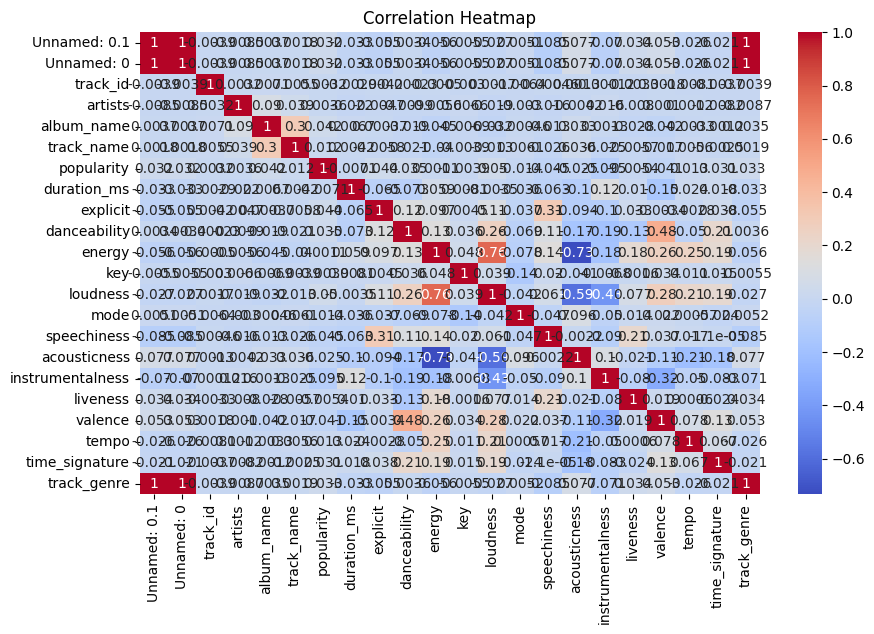

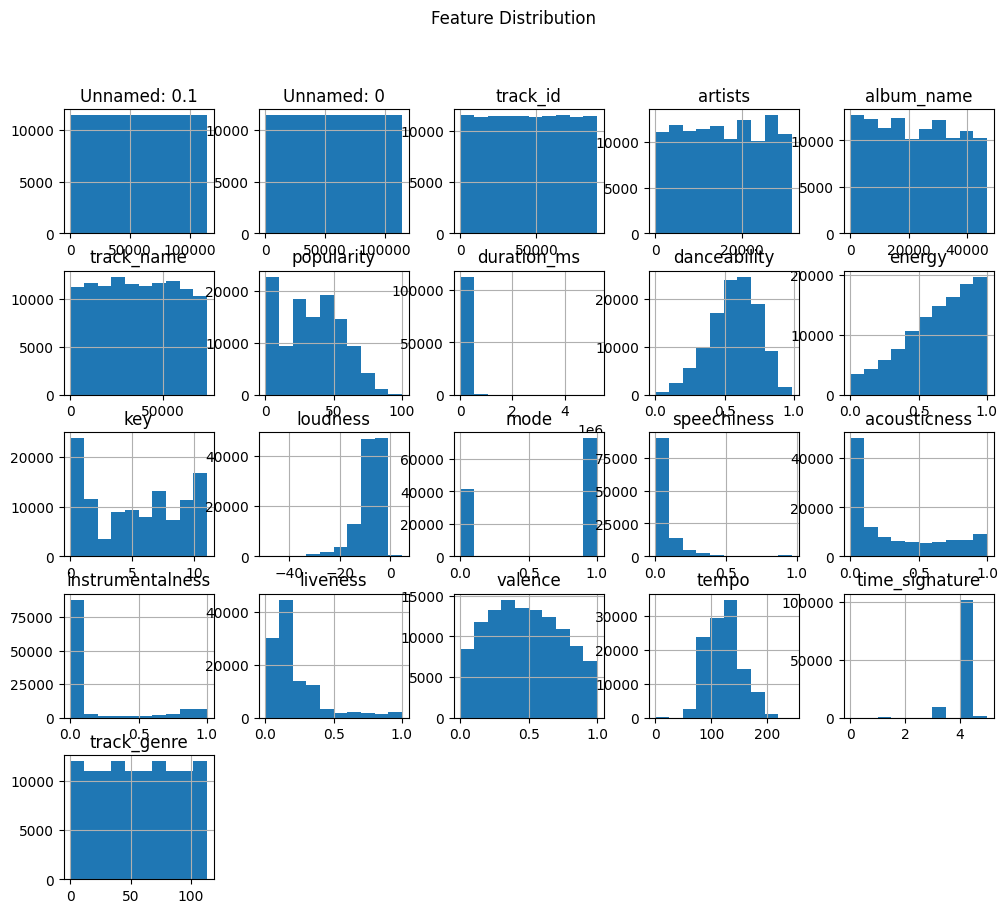

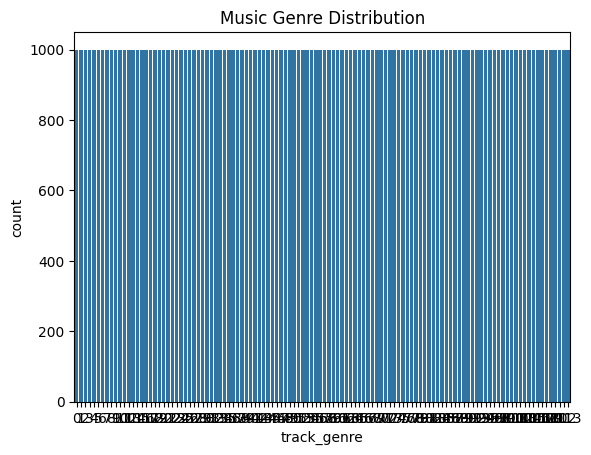

In [24]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Distribution plots
df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

# Count plot (Target column assumed last)
target_column = df.columns[-1]

sns.countplot(x=df[target_column])
plt.title("Music Genre Distribution")
plt.show()

Step 5:Feature Selection & Train-Test Split

In [22]:
X = df.drop(columns=[target_column])
y = df[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (91200, 21)
Test Shape: (22800, 21)


Step 6:Model Training

In [10]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Logistic Regression (MAIN MODEL)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Step 7:Model Evaluation

In [11]:
# Predictions
y_pred = log_reg.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.2585858585858586

Confusion Matrix:
 [[156  26   0 ...   0   0   0]
 [ 14 147  32 ...   0   0   0]
 [  0  32 117 ...   0   0   0]
 ...
 [  0   0   0 ...  39  42   8]
 [  0   0   0 ...  22  97   8]
 [  0   0   0 ...  18  24   6]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89       182
           1       0.71      0.73      0.72       200
           2       0.56      0.56      0.56       209
           3       0.42      0.41      0.42       215
           4       0.28      0.22      0.25       205
           5       0.37      0.38      0.37       199
           6       0.36      0.37      0.37       198
           7       0.27      0.32      0.29       194
           8       0.18      0.04      0.06       213
           9       0.21      0.08      0.11       197
          10       0.19      0.15      0.17       215
          11       0.27      0.26      0.26       187
          12       0.40      0

Step 8:ROC Curve

/tmp/ipykernel_7215/1938132897.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


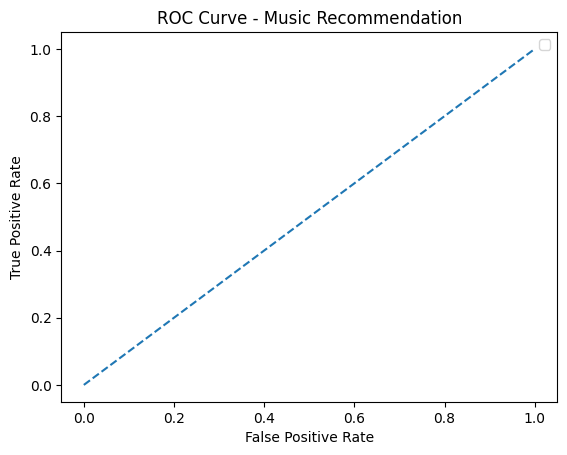

In [12]:
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Music Recommendation")
plt.legend()
plt.show()

Step 9:Sample Predictions

In [13]:
sample = X_test.iloc[:5]
predictions = log_reg.predict(sample)

print("\nSample Predictions:")
for i, pred in enumerate(predictions):
    print(f"User {i+1} → Recommended Music Genre: {pred}")


Sample Predictions:
User 1 → Recommended Music Genre: 31
User 2 → Recommended Music Genre: 20
User 3 → Recommended Music Genre: 31
User 4 → Recommended Music Genre: 24
User 5 → Recommended Music Genre: 31


Step 10:Prediction Visualization

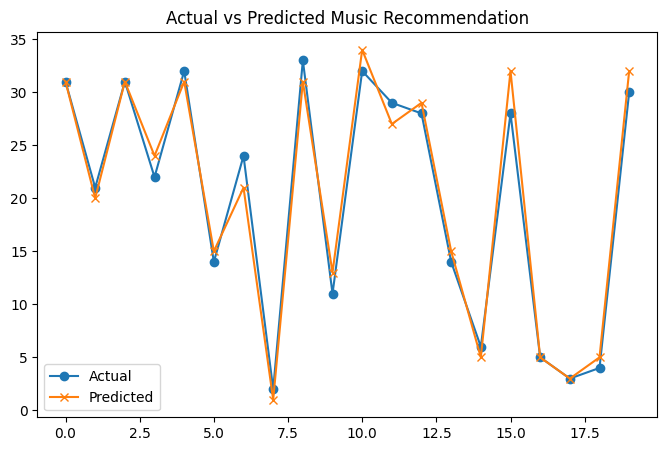

In [14]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:20], label="Actual", marker='o')
plt.plot(y_pred[:20], label="Predicted", marker='x')
plt.title("Actual vs Predicted Music Recommendation")
plt.legend()
plt.show()

Step 11:Final Recommendation Example

In [15]:
# Example input (first row)
new_user = np.array([X.iloc[0]])

prediction = log_reg.predict(new_user)

print("\nFinal Music Recommendation:")
print("Recommended Genre:", prediction[0])


Final Music Recommendation:
Recommended Genre: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
